In [68]:
## Dataset Reading 
import pandas as pd
import numpy as np
df = pd.read_csv("processed_data.csv")
df

,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,ca,target,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,1,145.0,233.0,1,150.0,0,2.3,0.0,0,0,0,1,0,0,0,0,0,0
1,67,1,160.0,286.0,0,108.0,1,1.5,3.0,1,0,0,0,0,0,1,0,1,0
2,67,1,120.0,229.0,0,129.0,1,2.6,2.0,1,0,0,0,0,0,1,0,0,1
3,37,1,130.0,250.0,0,187.0,0,3.5,0.0,0,0,1,0,1,0,0,0,1,0
4,41,0,130.0,204.0,0,172.0,0,1.4,0.0,0,1,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54,0,127.0,333.0,1,154.0,0,0.0,0.0,1,0,0,0,0,1,1,0,1,0
916,62,1,130.0,139.0,0,140.0,0,0.5,0.0,0,0,0,1,0,1,1,0,1,0
917,55,1,122.0,223.0,1,100.0,0,0.0,0.0,1,0,0,0,0,1,1,0,0,0
918,58,1,130.0,385.0,1,140.0,0,0.5,0.0,0,0,0,0,0,0,1,0,1,0


In [69]:
from sklearn.model_selection import train_test_split
columns = df.columns
columns = columns.drop("target")
X = df[columns]
X.shape

(920, 18)

In [70]:
Y = df["target"]

In [71]:
X_train , X_test , y_train , y_test = train_test_split(X, Y , test_size=0.2 , random_state=42)

In [72]:
X_train

,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,ca,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
880,62,1,130.0,170.0,0,120.0,1,3.0,0.0,0,0,0,0,1,1,0,1,0
457,54,1,150.0,223.0,0,122.0,0,0.0,0.0,0,1,0,1,0,1,0,1,0
797,51,1,130.0,339.0,0,140.0,0,0.5,0.0,0,1,0,1,0,1,0,1,0
25,50,0,120.0,219.0,0,158.0,0,1.6,0.0,0,1,0,1,0,1,0,1,0
84,52,1,120.0,325.0,0,172.0,0,0.2,0.0,1,0,0,1,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,59,1,140.0,177.0,0,162.0,1,0.0,1.0,0,0,0,1,0,0,1,0,1
270,61,1,140.0,207.0,0,138.0,1,1.9,1.0,0,0,0,0,0,0,1,0,1
860,75,1,160.0,310.0,1,112.0,1,2.0,0.0,0,0,0,1,0,0,0,0,1
435,53,0,140.0,216.0,0,142.0,1,2.0,0.0,1,0,0,1,0,1,0,1,0


In [73]:
## Applying Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train , y_train)

DecisionTreeClassifier(random_state=42)

In [74]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 1])

In [75]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pred , y_test)

0.7989130434782609

In [76]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[58 17]
 [20 89]]


In [77]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.77      0.76        75
           1       0.84      0.82      0.83       109

    accuracy                           0.80       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.80      0.80      0.80       184



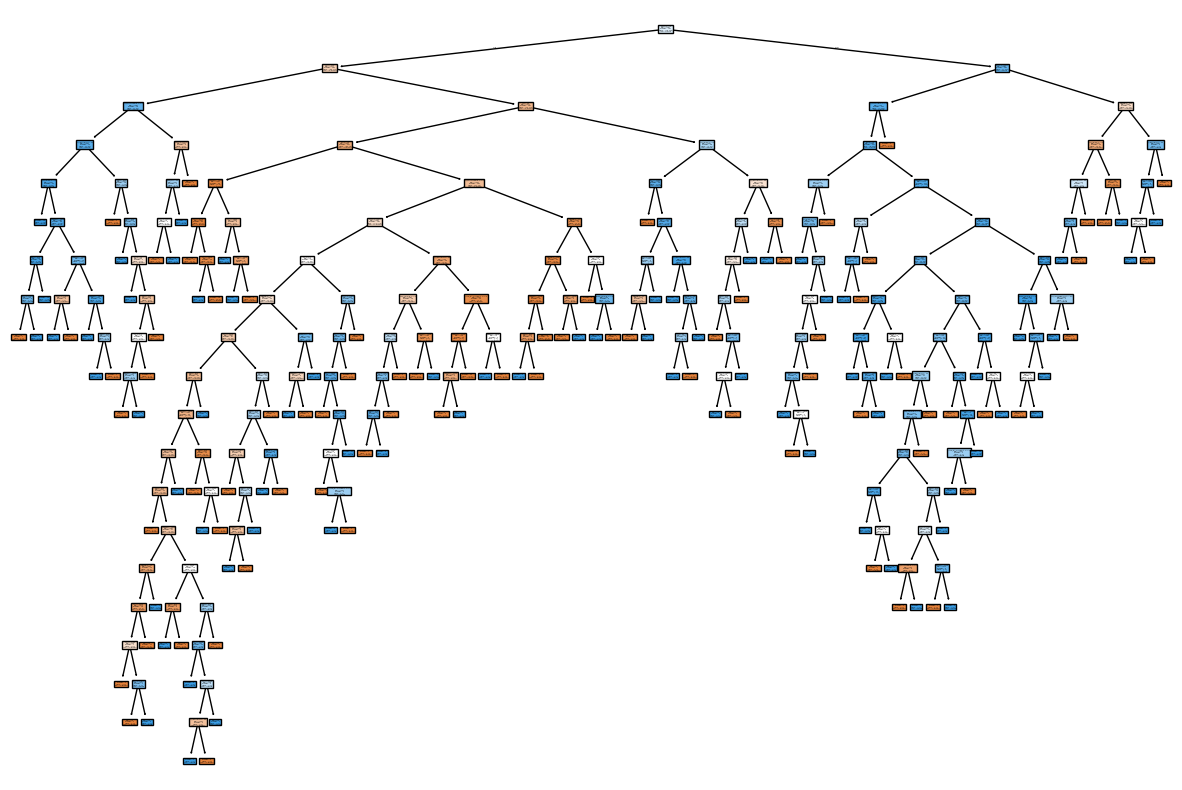

In [78]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No Disease","Disease"],
    filled=True
)

plt.show()

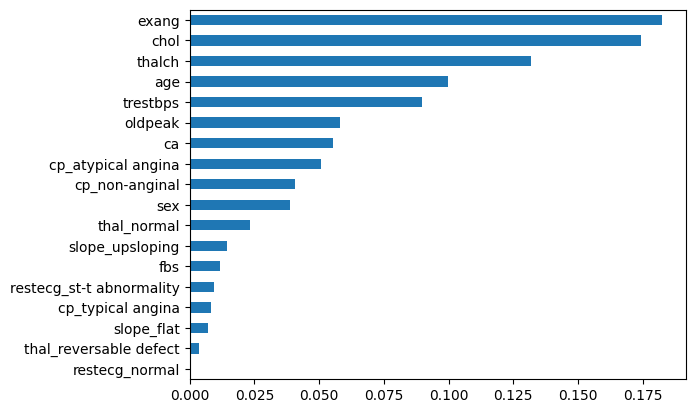

In [79]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)

importance.sort_values().plot(kind="barh")

plt.show()

In [118]:
## Modified Decision Tree

model2 = DecisionTreeClassifier(
    max_depth = 10,
    min_samples_split=10,
    min_samples_leaf=2,
    random_state=42,
   
)
model2.fit(X_train , y_train)
y_pred2 = model2.predict(X_test)


In [119]:
y_pred2

array([0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 1])

In [120]:
accuracy_score(y_pred2 , y_test)

0.8260869565217391

In [121]:
cm = confusion_matrix(y_test, y_pred2)
cm

array([[60, 15],
       [17, 92]])

In [122]:
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       0.78      0.80      0.79        75
           1       0.86      0.84      0.85       109

    accuracy                           0.83       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.83      0.83      0.83       184



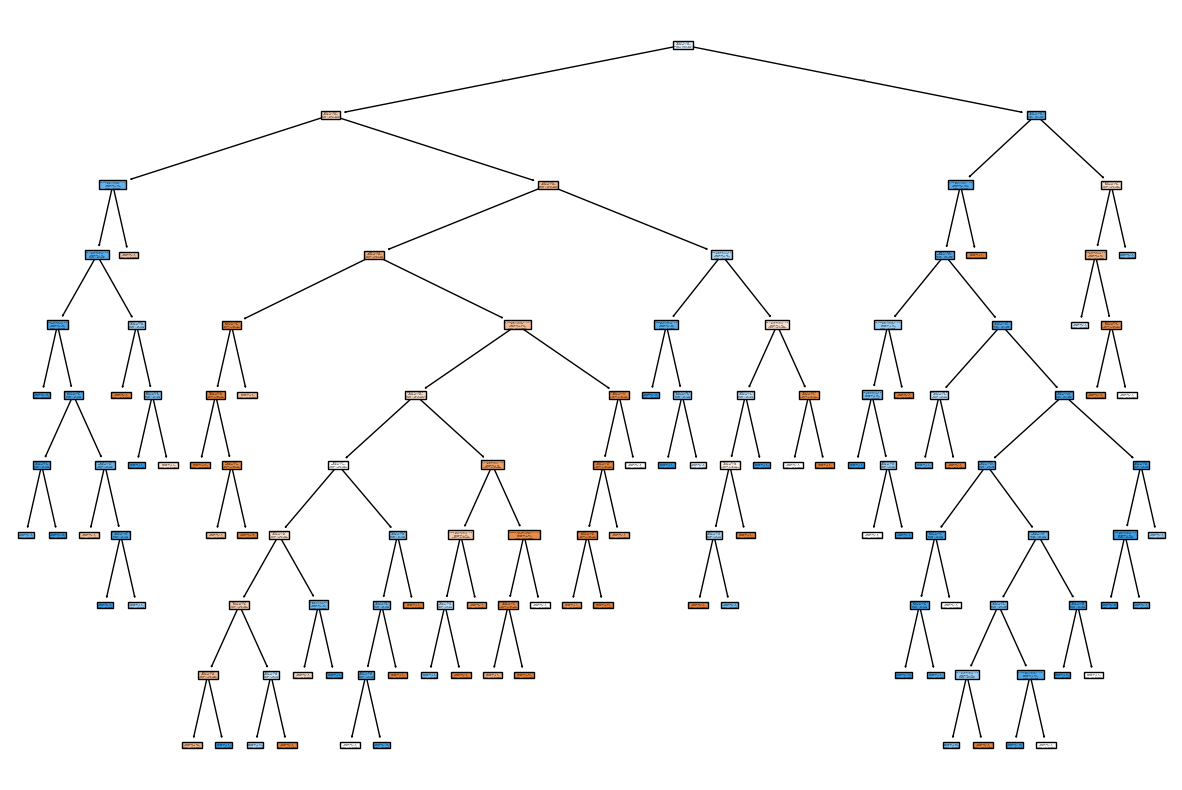

In [125]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))

plot_tree(
    model2,
    feature_names=X.columns,
    class_names=["No Disease","Disease"],
    filled=True
)

plt.show()

In [124]:
probs = model2.predict_proba(X_test)
probs

array([[1.        , 0.        ],
       [1.        , 0.        ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [1.        , 0.        ],
       [0.66666667, 0.33333333],
       [0.25      , 0.75      ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.05555556, 0.94444444],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.72881356, 0.27118644],
       [1.        , 0.        ],
       [0.25      , 0.75      ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.85714286, 0.14285714],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.05555556, 0.94444444],
       [0.22222222, 0.77777778],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [1.        , 0.        ],
       [0.05555556, 0.94444444],
       [0.72881356, 0.27118644],
       [1.

[Text(0.5, 0.9, 'x[6] <= 0.5\ngini = 0.496\nsamples = 736\nvalue = [336, 400]'),
 Text(0.22, 0.7, 'x[3] <= 42.5\ngini = 0.472\nsamples = 468\nvalue = [289, 179]'),
 Text(0.36, 0.8, 'True  '),
 Text(0.12, 0.5, 'x[9] <= 0.5\ngini = 0.295\nsamples = 78\nvalue = [14, 64]'),
 Text(0.08, 0.3, 'x[10] <= 0.5\ngini = 0.239\nsamples = 72\nvalue = [10, 62]'),
 Text(0.04, 0.1, 'gini = 0.137\nsamples = 54\nvalue = [4, 50]'),
 Text(0.12, 0.1, 'gini = 0.444\nsamples = 18\nvalue = [6, 12]'),
 Text(0.16, 0.3, 'gini = 0.444\nsamples = 6\nvalue = [4, 2]'),
 Text(0.32, 0.5, 'x[8] <= 0.5\ngini = 0.416\nsamples = 390\nvalue = [275, 115]'),
 Text(0.24, 0.3, 'x[1] <= 0.5\ngini = 0.359\nsamples = 332\nvalue = [254, 78]'),
 Text(0.2, 0.1, 'gini = 0.061\nsamples = 96\nvalue = [93, 3]'),
 Text(0.28, 0.1, 'gini = 0.434\nsamples = 236\nvalue = [161, 75]'),
 Text(0.4, 0.3, 'x[16] <= 0.5\ngini = 0.462\nsamples = 58\nvalue = [21, 37]'),
 Text(0.36, 0.1, 'gini = 0.245\nsamples = 28\nvalue = [4, 24]'),
 Text(0.44, 0.1, 

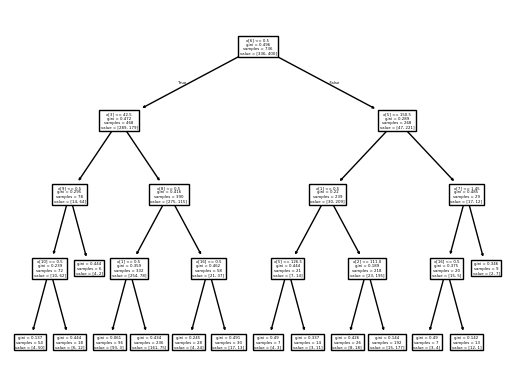

In [22]:
from sklearn.tree import plot_tree
plot_tree(model2)

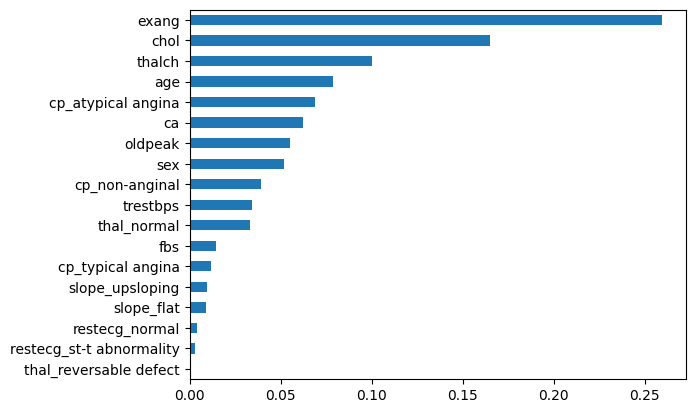

In [126]:
import pandas as pd

importance = pd.Series(model2.feature_importances_, index=X.columns)

importance.sort_values().plot(kind="barh")

plt.show()